     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
Precomputing ground states via Exact Diagonalization...
Running grid evaluation at noise level p = 0.0...
Running grid evaluation at noise level p = 0.01...
Running grid evaluation at noise level p = 0.05...
Sav

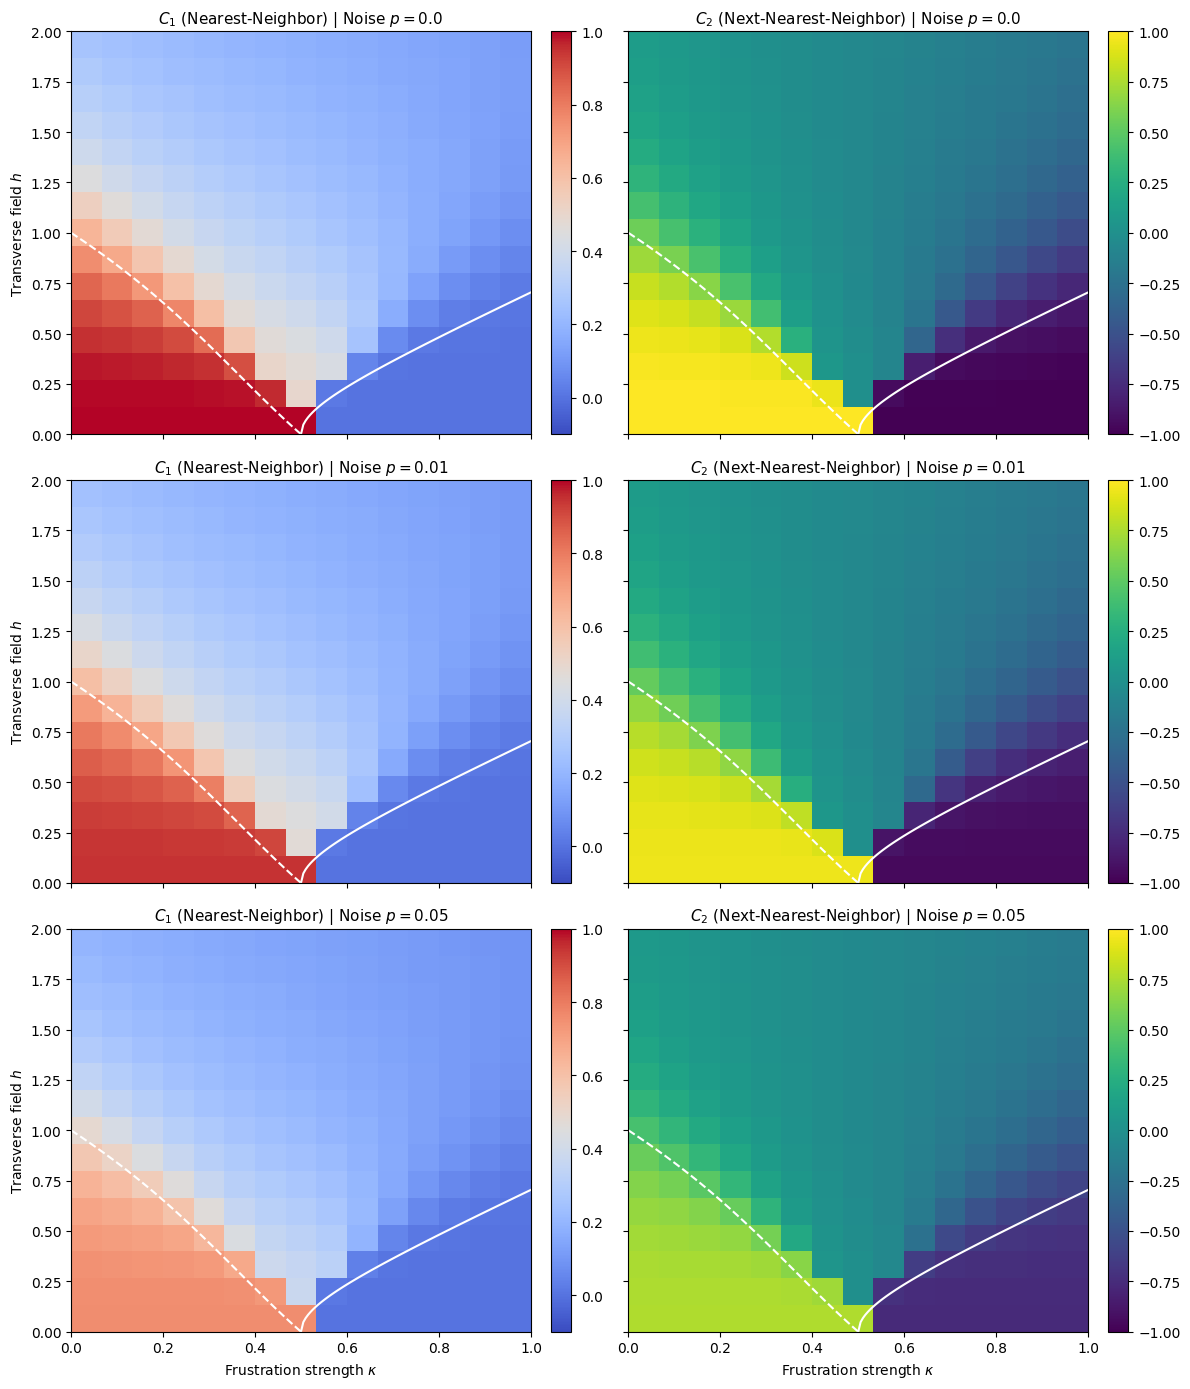

In [ ]:
!pip install pennylane
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import scipy.linalg

# ==========================================
# 1. ANNNI Hamiltonian Construction
# ==========================================
def build_annni_hamiltonian(n_qubits, kappa, h, j1=1.0, periodic=True):
    coeffs = []
    obs = []

    # Nearest-neighbor terms
    for i in range(n_qubits - 1 + int(periodic)):
        coeffs.append(-j1)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i + 1) % n_qubits))

    # Next-nearest-neighbor terms
    for i in range(n_qubits - 2 + 2 * int(periodic)):
        coeffs.append(j1 * kappa)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i + 2) % n_qubits))

    # Transverse field terms
    for i in range(n_qubits):
        coeffs.append(-h)
        obs.append(qml.X(i))

    return qml.dot(coeffs, obs)

# ==========================================
# 2. Analytical Boundaries for Reference
# ==========================================
def ising_transition(k):
    k = np.asarray(k, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        res = (1 - k) * (1 - np.sqrt((1 - 3 * k + 4 * k**2) / (1 - k))) / np.maximum(k, 1e-9)
    return np.where(k == 0, 1.0, res)

def kt_transition(k):
    k = np.asarray(k, dtype=float)
    return 1.05 * np.sqrt(np.maximum(0, (k - 0.5) * (k - 0.1)))

# ==========================================
# 3. Define Noisy Quantum Circuit
# ==========================================
n_qubits = 8
dev_mixed = qml.device("default.mixed", wires=n_qubits)

@qml.qnode(dev_mixed)
def noisy_correlation_circuit(state, p):
    # Prepare the exact ground state
    qml.StatePrep(state, wires=range(n_qubits))

    # Apply depolarizing noise across neighboring qubit interactions
    if p > 0:
        for i in range(n_qubits):
            ctrl = i
            tgt = (i + 1) % n_qubits
            qml.CNOT(wires=[ctrl, tgt])
            qml.DepolarizingChannel(p, wires=tgt)
            qml.CNOT(wires=[ctrl, tgt])
            qml.DepolarizingChannel(p, wires=tgt)

    # Return correlation expectation values
    c1_terms = [qml.expval(qml.Z(i) @ qml.Z((i + 1) % n_qubits)) for i in range(n_qubits)]
    c2_terms = [qml.expval(qml.Z(i) @ qml.Z((i + 2) % n_qubits)) for i in range(n_qubits)]
    return c1_terms, c2_terms

# ==========================================
# 4. Main Execution Grid Evaluation
# ==========================================
if __name__ == "__main__":
    grid_size = 15
    kappa_vals = np.linspace(0.0, 1.0, grid_size)
    h_vals = np.linspace(0.0, 2.0, grid_size)
    noise_levels = [0.0, 0.01, 0.05]

    # Precompute exact ground states via exact diagonalization
    print("Precomputing ground states via Exact Diagonalization...")
    ground_states = np.empty((grid_size, grid_size, 2**n_qubits), dtype=complex)
    for y, h in enumerate(h_vals):
        for x, kappa in enumerate(kappa_vals):
            H = build_annni_hamiltonian(n_qubits, kappa=kappa, h=h)
            _, eigenvectors = scipy.linalg.eigh(qml.matrix(H))
            ground_states[y, x] = eigenvectors[:, 0]

    # Set up figure
    fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharex=True, sharey=True)
    k_low = np.linspace(0.0, 0.5, 100)
    k_high = np.linspace(0.5, 1.0, 100)

    # Dynamic extent map based on true values: [xmin, xmax, ymin, ymax]
    plot_extent = [kappa_vals.min(), kappa_vals.max(), h_vals.min(), h_vals.max()]

    for idx, p in enumerate(noise_levels):
        print(f"Running grid evaluation at noise level p = {p}...")
        c1_grid = np.zeros((grid_size, grid_size))
        c2_grid = np.zeros((grid_size, grid_size))

        for y in range(grid_size):
            for x in range(grid_size):
                psi = ground_states[y, x]
                c1_vals, c2_vals = noisy_correlation_circuit(psi, p)
                # Unwrap expectations from tensor structures to averages
                c1_grid[y, x] = np.mean([float(val) for val in c1_vals])
                c2_grid[y, x] = np.mean([float(val) for val in c2_vals])

        # --- Plot C1 Heatmap (Nearest-Neighbor) ---
        im1 = axes[idx, 0].imshow(
            c1_grid, extent=plot_extent, origin="lower", aspect="auto", cmap="coolwarm", vmin=-0.1, vmax=1.0
        )
        axes[idx, 0].plot(k_low, ising_transition(k_low), "w--", lw=1.5, label="Ising Transition" if idx==0 else "")
        axes[idx, 0].plot(k_high, kt_transition(k_high), "w-", lw=1.5, label="KT Transition" if idx==0 else "")
        axes[idx, 0].set_title(f"$C_1$ (Nearest-Neighbor) | Noise $p = {p}$", fontsize=11)
        axes[idx, 0].set_ylabel(r"Transverse field $h$")
        fig.colorbar(im1, ax=axes[idx, 0], fraction=0.046, pad=0.04)

        # --- Plot C2 Heatmap (Next-Nearest-Neighbor) ---
        im2 = axes[idx, 1].imshow(
            c2_grid, extent=plot_extent, origin="lower", aspect="auto", cmap="viridis", vmin=-1.0, vmax=1.0
        )
        axes[idx, 1].plot(k_low, ising_transition(k_low), "w--", lw=1.5)
        axes[idx, 1].plot(k_high, kt_transition(k_high), "w-", lw=1.5)
        axes[idx, 1].set_title(f"$C_2$ (Next-Nearest-Neighbor) | Noise $p = {p}$", fontsize=11)
        fig.colorbar(im2, ax=axes[idx, 1], fraction=0.046, pad=0.04)

    # Set bottom labels safely using exact grid axis layout dimensions
    axes[2, 0].set_xlabel(r"Frustration strength $\kappa$")
    axes[2, 1].set_xlabel(r"Frustration strength $\kappa$")

    plt.tight_layout()
    plt.savefig("noisy_phase_diagrams_comparison.png", dpi=300)
    print("Saved noisy comparison plot to 'noisy_phase_diagrams_comparison.png'")
    plt.show()
